In [2]:
'''
Convolutional neural network (CNN) 
Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into
categories.
'''

'\nConvolutional neural network (CNN) \nUse MNIST Fashion Dataset and create a classifier to classify fashion clothing into\ncategories.\n'

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [2]:
import tensorflow_datasets as tfds

ds, info = tfds.load(
    'fashion_mnist',
    with_info=True
)

print(info.features['label'].names)

ModuleNotFoundError: No module named 'tensorflow_datasets'

In [5]:
(x_train,y_train), (x_test,y_test)= tf.keras.datasets.fashion_mnist.load_data()

In [6]:
# Class Labels
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]


In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [8]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [9]:
y_train_cat= to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [17]:
model=Sequential()

In [18]:
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

In [19]:
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

In [20]:
model.add(Flatten())

In [21]:
# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

In [22]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(x_train,y_train_cat,epochs=10,batch_size=64,validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.7675 - loss: 0.6469 - val_accuracy: 0.8602 - val_loss: 0.3998
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.8455 - loss: 0.4273 - val_accuracy: 0.8736 - val_loss: 0.3412
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.8680 - loss: 0.3714 - val_accuracy: 0.8867 - val_loss: 0.3100
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.8776 - loss: 0.3381 - val_accuracy: 0.8916 - val_loss: 0.2955
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.8854 - loss: 0.3153 - val_accuracy: 0.8964 - val_loss: 0.2799
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.8927 - loss: 0.2927 - val_accuracy: 0.8981 - val_loss: 0.2758
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9006 - loss: 0.2746 - val_accuracy: 0.9003 - val_loss: 0.2679
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9055 - loss: 0.2590 - 

In [25]:
loss,accuracy=model.evaluate(x_test,y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9042 - loss: 0.2570


In [26]:
print("\nTest Accuracy:", accuracy)



Test Accuracy: 0.90420001745224


In [27]:

# Predictions
y_pred = model.predict(x_test)
y_pred_classes = y_pred.argmax(axis=1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

# Display Sample Predictions
plt.figure(figsize=(10,10))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1000
           1       0.98      0.98      0.98      1000
           2       0.89      0.84      0.86      1000
           3       0.92      0.89      0.90      1000
           4       0.84      0.88      0.86      1000
           5       0.98      0.98      0.98      1000
           6       0.70      0.72      0.71      1000
           7       0.97      0.96      0.96      1000
           8       0.97      0.98      0.97      1000
           9       0.96      0.97      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

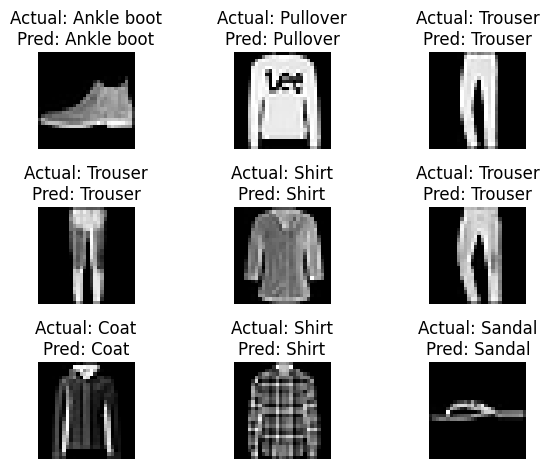

In [28]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Actual: {class_names[y_test[i]]}\nPred: {class_names[y_pred_classes[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()